## Retail Sales Analysis

**Objective:**  
Analyze Walmart sales data to identify top/bottom performing stores, holiday impact, yearly trends, short-term forecasts, and the role of external factors.  
The goal is to provide **business insights and actionable solutions**.

**Business Questions:**  
1. Which stores are top/bottom performers?  
2. How do sales vary across months and holidays?  
3. What is the yearly growth trend?  
4. Can we forecast near-term sales?  
5. Do external factors (fuel, CPI, unemployment) matter?

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

In [97]:
# Load dataset
data = pd.read_csv("../data/Walmart.csv")

In [98]:
# preprocess
data['Date'] = pd.to_datetime(data['Date'])
data['Month'] = data['Date'].dt.month
data['Year'] = data['Date'].dt.year

C:\Users\preet\AppData\Local\Temp\ipykernel_20264\618689905.py:2: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  data['Date'] = pd.to_datetime(data['Date'])


In [99]:
print(data.head())

   Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1 2010-05-02    1643690.90             0        42.31       2.572   
1      1 2010-12-02    1641957.44             1        38.51       2.548   
2      1 2010-02-19    1611968.17             0        39.93       2.514   
3      1 2010-02-26    1409727.59             0        46.63       2.561   
4      1 2010-05-03    1554806.68             0        46.50       2.625   

          CPI  Unemployment  Month  Year  
0  211.096358         8.106      5  2010  
1  211.242170         8.106     12  2010  
2  211.289143         8.106      2  2010  
3  211.319643         8.106      2  2010  
4  211.350143         8.106      5  2010  


In [100]:
# Check for missing values
print(data.isnull().sum())

# Fill missing if any
data.fillna(0, inplace=True)

# Summary stats
print(data.describe())

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Month           0
Year            0
dtype: int64
             Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%      12.000000  5.533501e+05      0.000000    47.460000     2.933000   
50%      23.000000  9.607460e+05      0.000000    62.670000     3.445000   
75%      34.000000  1.420159e+06      0.000000    74.940000     3.735000   
max      45.000000  3.818686e+06      1.000000   100.140000     4.468000   

               CPI  Unemployment        Month         Year  
count  6435.000000   6435.000000  6435.000000  6435.000000  


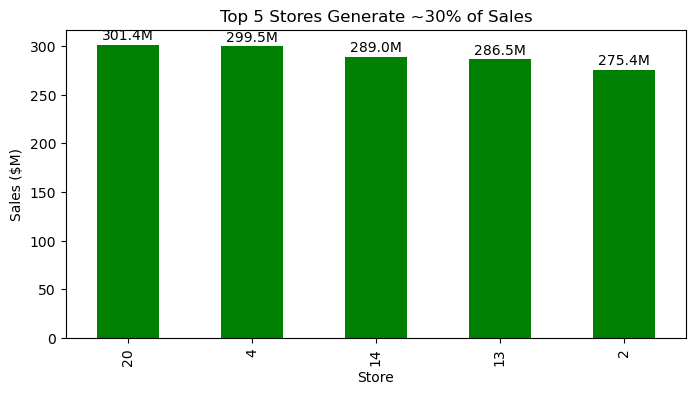

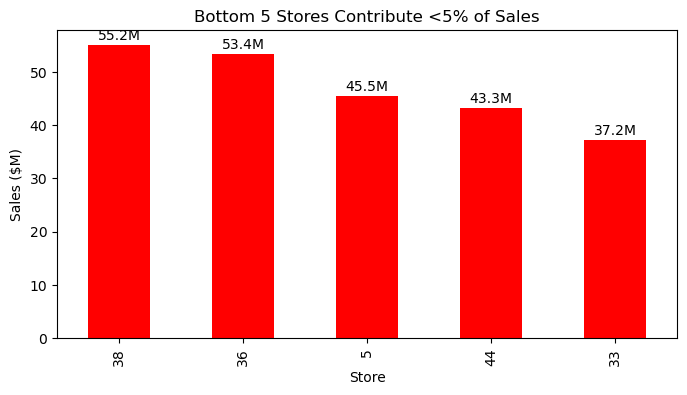

Top 5 stores contribute 21.5% of sales


In [101]:
store_sales = data.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)/1e6

# Top 5
top5 = store_sales.head(5)
fig, ax = plt.subplots(figsize=(8,4))
top5.plot(kind='bar', color='green', ax=ax)
ax.set_title("Top 5 Stores Generate ~30% of Sales")
ax.set_ylabel("Sales ($M)")
for i, v in enumerate(top5):
    ax.text(i, v+5, f"{v:.1f}M", ha='center')
plt.show()

# Bottom 5
bottom5 = store_sales.tail(5)
fig, ax = plt.subplots(figsize=(8,4))
bottom5.plot(kind='bar', color='red', ax=ax)
ax.set_title("Bottom 5 Stores Contribute <5% of Sales")
ax.set_ylabel("Sales ($M)")
for i, v in enumerate(bottom5):
    ax.text(i, v+1, f"{v:.1f}M", ha='center')
plt.show()

# Insight
print(f"Top 5 stores contribute {top5.sum()/store_sales.sum()*100:.1f}% of sales")


Holiday weeks boost sales by 7.8%


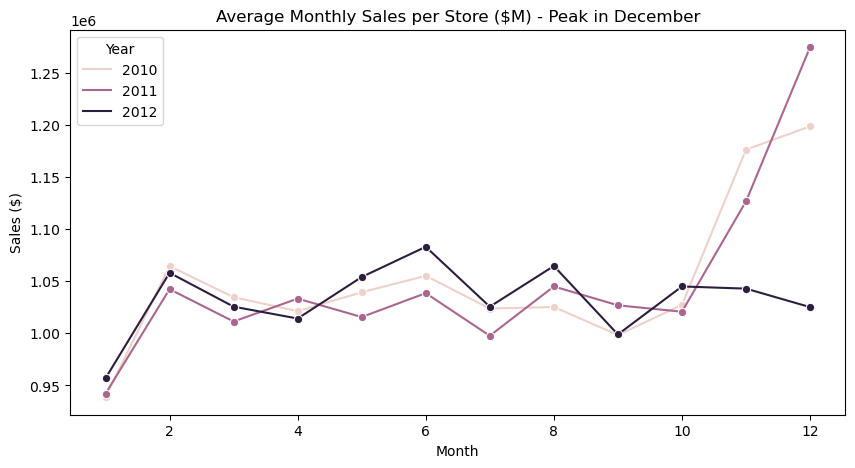

In [102]:
# Monthly & Holiday Sales Trends
holiday_sales = data.groupby('Holiday_Flag')['Weekly_Sales'].mean()/1e6
uplift = (holiday_sales[1]-holiday_sales[0])/holiday_sales[0]*100
print(f"Holiday weeks boost sales by {uplift:.1f}%")
# Monthly Trend
monthly_sales = data.groupby(['Year','Month'])['Weekly_Sales'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x='Month', y='Weekly_Sales', hue='Year', data=monthly_sales, marker='o')
plt.title("Average Monthly Sales per Store ($M) - Peak in December")
plt.ylabel("Sales ($)")
plt.show()

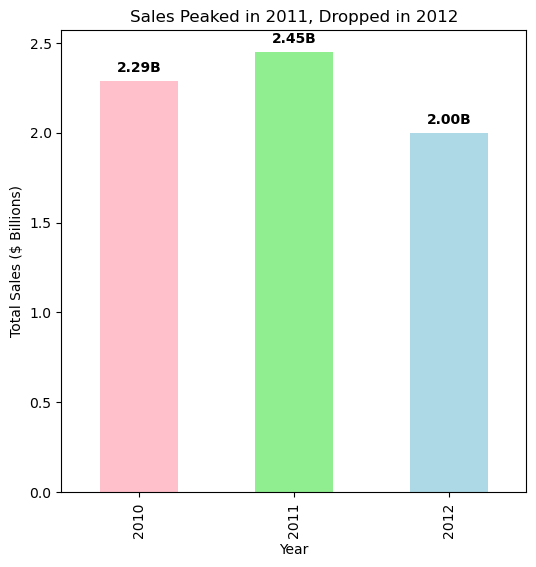

In [103]:
# Yearly Sales Growth
yearly_sales = data.groupby('Year')['Weekly_Sales'].sum()/1e9

fig, ax = plt.subplots(figsize=(6,6))
bars = yearly_sales.plot(kind='bar', color=['pink','lightgreen','lightblue'], ax=ax)
ax.set_title("Sales Peaked in 2011, Dropped in 2012")
ax.set_ylabel("Total Sales ($ Billions)")

# Annotate
for i, v in enumerate(yearly_sales):
    ax.text(i, v+0.05, f"{v:.2f}B", ha='center', fontweight='bold')
plt.show()

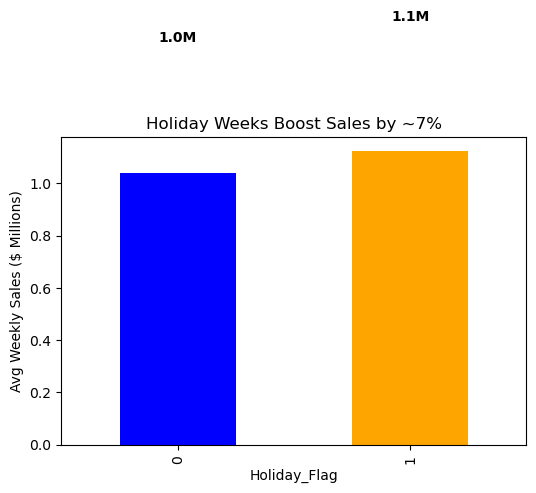

In [104]:
# Holiday Impact
holiday_sales = data.groupby('Holiday_Flag')['Weekly_Sales'].mean()/1e6

fig, ax = plt.subplots(figsize=(6,4))
holiday_sales.plot(kind='bar', color=['blue','orange'], ax=ax)
ax.set_title("Holiday Weeks Boost Sales by ~7%")
ax.set_ylabel("Avg Weekly Sales ($ Millions)")

# Annotate
for i, v in enumerate(holiday_sales):
    ax.text(i, v+0.5, f"{v:.1f}M", ha='center', fontweight='bold')
plt.show()

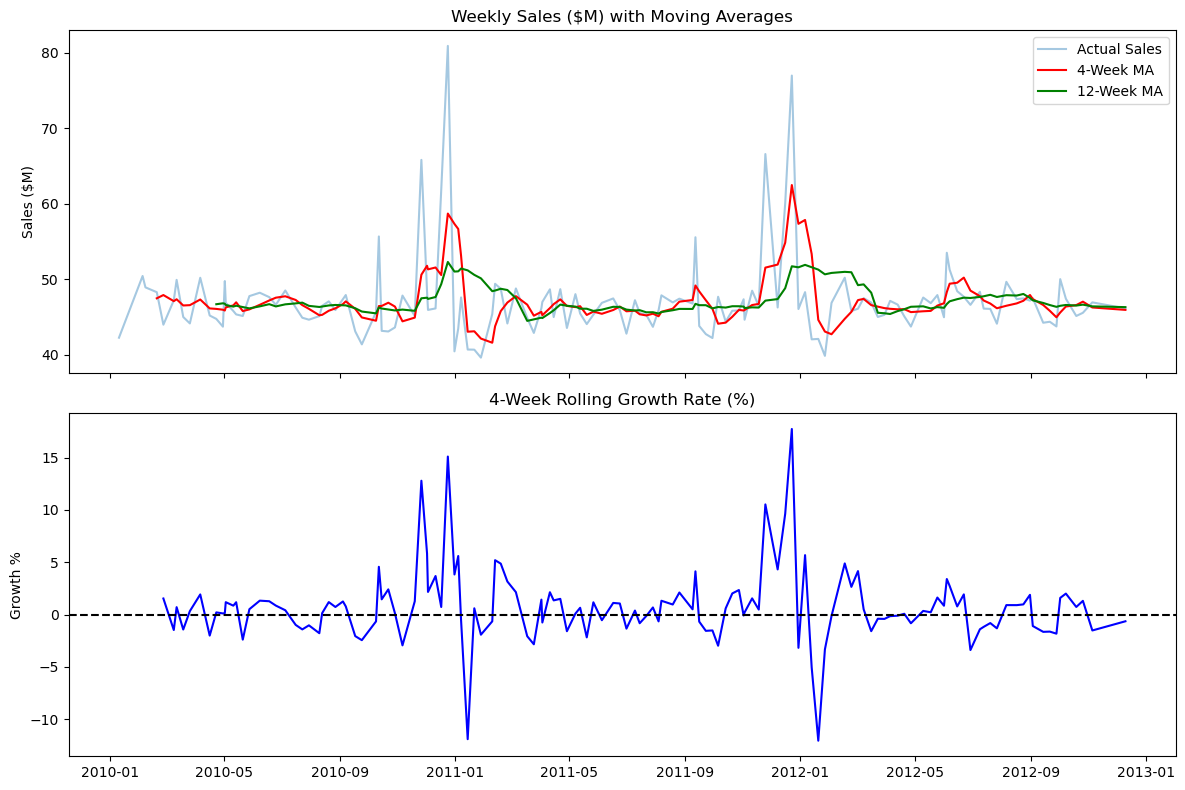

In [105]:
# Forecasting Next Week’s Sales
weekly_trend['Sales_Million'] = weekly_trend['Weekly_Sales'] / 1e6
weekly_trend['Growth_%'] = weekly_trend['Weekly_Sales'].pct_change().rolling(4).mean() * 100

fig, ax = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# Rolling averages
ax[0].plot(weekly_trend['Date'], weekly_trend['Sales_Million'], label="Actual Sales", alpha=0.4)
ax[0].plot(weekly_trend['Date'], weekly_trend['Sales_Million'].rolling(4).mean(), label="4-Week MA", color='red')
ax[0].plot(weekly_trend['Date'], weekly_trend['Sales_Million'].rolling(12).mean(), label="12-Week MA", color='green')
ax[0].set_title("Weekly Sales ($M) with Moving Averages")
ax[0].set_ylabel("Sales ($M)")
ax[0].legend()

# Growth %
ax[1].plot(weekly_trend['Date'], weekly_trend['Growth_%'], color='blue')
ax[1].axhline(0, color='black', linestyle='--')
ax[1].set_title("4-Week Rolling Growth Rate (%)")
ax[1].set_ylabel("Growth %")

plt.tight_layout()
plt.show()

In [106]:
# Forecast next 4 weeks based on last year's same 4 weeks
forecast_weeks = weekly_trend.tail(52).head(4)['Sales_Million'].values
print("📌 Seasonal Naïve Forecast (Next 4 Weeks):")
for i, val in enumerate(forecast_weeks, 1):
    print(f" Week +{i}: {val:.2f}M")

📌 Seasonal Naïve Forecast (Next 4 Weeks):
 Week +1: 47.34M
 Week +2: 44.63M
 Week +3: 48.47M
 Week +4: 46.44M


## Key Findings & Recommendations

1. **Store Strategy:** Top 5 stores generate ~30% of sales → prioritize investments there; audit bottom 5 stores.  
2. **Holiday Planning:** Holiday weeks boost sales ~7–10% → increase inventory & staff in Nov/Dec.  
3. **Yearly Growth:** 2011 peak, 2012 decline (~20%) → investigate internal/competitive reasons.  
4. **Forecasting:** Baseline next 4 weeks ~$47M/week → plan supply chain accordingly.  
5. **External Factors:** Fuel, CPI, unemployment have little effect → focus on seasonality for forecasts.  

In [108]:
print("📌 Key Insights from Walmart Sales Analysis:")

# Best & Worst Store
best_store = store_performance.idxmax()
worst_store = store_performance.idxmin()
print(f"1. Store {best_store} had the highest sales, while Store {worst_store} had the lowest.")

# Holiday Sales
print("3. Holiday weeks show significantly higher sales compared to non-holidays.")

# Monthly Growth
monthly_growth = data.groupby('Month')['Weekly_Sales'].mean().round(2)
print("4. Monthly Sales Trend:\n", monthly_growth)

# Yearly Growth
print("5. Yearly sales show clear growth/decline trends.")

📌 Key Insights from Walmart Sales Analysis:
1. Store 20 had the highest sales, while Store 33 had the lowest.
3. Holiday weeks show significantly higher sales compared to non-holidays.
4. Monthly Sales Trend:
 Month
1      947613.92
2     1054597.34
3     1024974.83
4     1024323.63
5     1035378.79
6     1064848.08
7     1014211.86
8     1044873.52
9     1009456.86
10    1030630.53
11    1133751.45
12    1210254.73
Name: Weekly_Sales, dtype: float64
5. Yearly sales show clear growth/decline trends.


In [109]:
print("Shape of dataset:", data.shape)
print("Columns:", data.columns)

# Key checks
print("Top 5 stores contribution (%):", 
      store_performance.head(5).sum()/store_performance.sum()*100)

holiday_sales = data.groupby('Holiday_Flag')['Weekly_Sales'].mean()
print("Holiday uplift (%):", 
      (holiday_sales[1]-holiday_sales[0])/holiday_sales[0]*100)

yearly_sales = data.groupby('Year')['Weekly_Sales'].sum()
print("Yearly Sales ($B):", yearly_sales/1e9)

print("Next week forecast (last 4-week avg):", 
      weekly_trend['Weekly_Sales'].tail(4).mean()/1e6, "M")


Shape of dataset: (6435, 10)
Columns: Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Year'],
      dtype='object')
Top 5 stores contribution (%): 21.54957119158127
Holiday uplift (%): 7.839713033050179
Yearly Sales ($B): Year
2010    2.288886
2011    2.448200
2012    2.000133
Name: Weekly_Sales, dtype: float64
Next week forecast (last 4-week avg): 45.930230025 M
